# SGNN: Stochastic SIR/SEIR/SEAIR


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
# NPI code

def sample_npi_parameters(N):
    # Deciding whether the outbreak will have NPI or not
    npi_enabled = np.random.rand() < 0.5

    # Default values
    npi_on_threshold = None
    npi_off_threshold = None
    npi_delay = 0
    npi_reduction = 1.0
    npi_min_duration = 0
    npi_off_days_required = 0

    # If NPI is turned on, choose its values
    if npi_enabled:
        # Pick the case level that turns NPI on
        npi_on_threshold = N * np.random.uniform(0.00001, 0.001)

        # Pick the case level that lets NPI turn off
        npi_off_threshold = npi_on_threshold * np.random.uniform(0.0, 1.0)

        # Pick how many days to wait before NPI starts
        npi_delay = np.random.randint(0, 21)

        # Pick how much beta should be reduced
        npi_reduction = np.random.uniform(0.2, 0.6)

        # Pick the minimum number of days NPI must stay active
        npi_min_duration = np.random.randint(14, 35)

        # Pick how many low-case days are needed before turning off NPI
        npi_off_days_required = np.random.randint(1, 50)

    # Return everything in a dictionary
    return {
        "npi_enabled": npi_enabled,
        "npi_on_threshold": npi_on_threshold,
        "npi_off_threshold": npi_off_threshold,
        "npi_delay": npi_delay,
        "npi_reduction": npi_reduction,
        "npi_min_duration": npi_min_duration,
        "npi_off_days_required": npi_off_days_required
    }

In [3]:
# beta update with NPI

def get_beta_with_npi(day, beta, daily_new_cases, npi_params, npi_state):
    # If this outbreak has no NPI, keep beta unchanged
    if not npi_params["npi_enabled"]:
        return beta

    # Get the most recent daily case count
    if len(daily_new_cases) > 0:
        current_cases = daily_new_cases[-1]
    else:
        current_cases = 0

    # If NPI is not active yet, check if it should be scheduled
    if not npi_state["active"] and npi_state["start_day"] is None:
        if current_cases >= npi_params["npi_on_threshold"]:
            npi_state["start_day"] = day + npi_params["npi_delay"]

    # If the scheduled start day has arrived, turn NPI on
    if not npi_state["active"] and npi_state["start_day"] is not None:
        if day >= npi_state["start_day"]:
            npi_state["active"] = True
            npi_state["days_active"] = 0
            npi_state["below_off_threshold_days"] = 0

    # If NPI is active, reduce beta
    if npi_state["active"]:
        npi_state["days_active"] += 1

        # Only check whether to turn off after the minimum duration
        if npi_state["days_active"] >= npi_params["npi_min_duration"]:
            if current_cases < npi_params["npi_off_threshold"]:
                npi_state["below_off_threshold_days"] += 1
            else:
                npi_state["below_off_threshold_days"] = 0

            # Turn NPI off after enough low-case days
            if npi_state["below_off_threshold_days"] >= npi_params["npi_off_days_required"]:
                npi_state["active"] = False
                npi_state["start_day"] = None
                npi_state["days_active"] = 0
                npi_state["below_off_threshold_days"] = 0
                return beta

        # Reduce beta while NPI is active
        return beta * npi_params["npi_reduction"]

    # If NPI is not active, return the original beta
    return beta

In [4]:
# reporting noise
def add_reporting_noise(true_cases):
    # Convert the list to a NumPy array
    true_cases = np.array(true_cases, dtype=int)

    # Choose how reporting changes from start to end
    reporting_rate_start = np.random.uniform(0.5, 0.8)
    reporting_rate_end = np.random.uniform(0.8, 0.98)

    # Make a smooth line of reporting rates
    reporting_rates = np.linspace(reporting_rate_start, reporting_rate_end, len(true_cases))

    # Create an array for the reported cases
    reported_cases = np.zeros(len(true_cases), dtype=float)

    # Under-report the true cases using binomial sampling
    for t in range(len(true_cases)):
        reported_cases[t] = np.random.binomial(true_cases[t], reporting_rates[t])

    # Decide if weekday effects will be used
    weekday_effect_applied = np.random.rand() < 0.5
    weekday_start_offset = None

    # If weekday effects are used, apply them
    if weekday_effect_applied:
        weekday_factors = np.array([1.15, 1.0, 1.0, 1.0, 0.9, 0.75, 0.65])
        weekday_start_offset = np.random.randint(0, 7)

        for t in range(len(reported_cases)):
            weekday = (t + weekday_start_offset) % 7
            reported_cases[t] = reported_cases[t] * weekday_factors[weekday]

    # Round the numbers and remove any negative values
    reported_cases = np.round(np.clip(reported_cases, 0, None)).astype(int)

    # Store the reporting settings
    reporting_info = {
        "reporting_rate_start": reporting_rate_start,
        "reporting_rate_end": reporting_rate_end,
        "weekday_effect_applied": weekday_effect_applied,
        "weekday_start_offset": weekday_start_offset
    }

    # Return the noisy cases and the settings
    return reported_cases, reporting_info

In [5]:
# post-outbreak cleanup

def enforce_no_post_outbreak_cases(true_cases, reported_cases):
    # Convert both lists to NumPy arrays
    true_cases = np.array(true_cases)
    reported_cases = np.array(reported_cases)

    # Find the days where the true cases are greater than zero
    nonzero_days = np.where(true_cases > 0)[0]

    # If there were no true cases, return the reported cases as they are
    if len(nonzero_days) == 0:
        return reported_cases.astype(int)

    # Find the last day with true cases
    last_true_day = nonzero_days[-1]

    # Set reported cases after the outbreak ends to zero
    reported_cases[last_true_day + 1:] = 0

    # Return integer values
    return reported_cases.astype(int)

In [6]:
# hospitalizations and deaths

def generate_hospitalizations_and_deaths(symptomatic_cases):
    # Convert the input to a NumPy array
    symptomatic_cases = np.array(symptomatic_cases, dtype=int)

    # Get the number of days
    num_days = len(symptomatic_cases)

    # Choose the hospitalization probability
    hosp_prob = np.random.uniform(0.02, 0.12)

    # Choose the probability of death after hospitalization
    death_prob_given_hosp = np.random.uniform(0.05, 0.2)

    # Choose the delay before hospitalization
    hosp_min_delay = np.random.randint(3, 6)
    hosp_max_delay = np.random.randint(7, 11)

    # Choose the delay before death
    death_min_delay = np.random.randint(5, 9)
    death_max_delay = np.random.randint(10, 18)

    # Create empty arrays for the outputs
    daily_hosp_true = np.zeros(num_days, dtype=int)
    daily_death_true = np.zeros(num_days, dtype=int)

    # Loop through every day
    for day in range(num_days):
        # Get today's symptomatic cases
        cases_today = symptomatic_cases[day]

        # Sample how many people are hospitalized
        n_hosp = np.random.binomial(cases_today, hosp_prob)

        # Place each hospitalization on a later day
        for i in range(n_hosp):
            hosp_delay = np.random.randint(hosp_min_delay, hosp_max_delay + 1)
            hosp_day = day + hosp_delay

            if hosp_day < num_days:
                daily_hosp_true[hosp_day] += 1

        # Sample how many hospitalized people die
        n_deaths = np.random.binomial(n_hosp, death_prob_given_hosp)

        # Place each death on a later day
        for i in range(n_deaths):
            death_delay = np.random.randint(death_min_delay, death_max_delay + 1)
            death_day = day + death_delay

            if death_day < num_days:
                daily_death_true[death_day] += 1

    # Save the settings used in this simulation
    hospital_death_info = {
        "hosp_prob": hosp_prob,
        "death_prob_given_hosp": death_prob_given_hosp,
        "hosp_min_delay": hosp_min_delay,
        "hosp_max_delay": hosp_max_delay,
        "death_min_delay": death_min_delay,
        "death_max_delay": death_max_delay
    }

    # Return the results and the settings
    return daily_hosp_true, daily_death_true, hospital_death_info

In [7]:
#SIR Simulation

# N = population size; T = Number of days to simulate
def simulate_sir(N = 200000, T = 128):
    # Random starting values
    # Transmission rate (beta-how fast infection spreads)
    beta = np.random.uniform(0.15, 0.45)
    
    # Recovery rate (gamma-how fast people recover)
    gamma = np.random.uniform(0.07, 0.25)
    
    # Infected people. This randomly chooses the starting number of infected people between 5 and 49
    I0 = np.random.randint(5, 50)

    # starting values
    # S-Susceptible people who can catch the disease
    S = N - I0
    # I-Infected people
    I = I0
    # R-Recovered people
    R = 0

    # history lists - these are empty lists that will store the values for each day
    S_hist = []
    I_hist = []
    R_hist = []
    # New infections each day
    new_inf_hist = []

    # Sample NPI settings for this outbreak
    npi_params = sample_npi_parameters(N)

    # Keeping track of NPI state
    npi_state = {
        "active": False,
        "start_day": None,
        "days_active": 0,
        "below_off_threshold_days": 0
    }

    # Store beta for each day
    beta_t_hist = []
    
    
    # simulating for for every day
    # This loop runs for each day from T = 0 to T = 127
    for day in range(T):

        beta_today = get_beta_with_npi(
            day=day,
            beta=beta,
            daily_new_cases=new_inf_hist,
            npi_params=npi_params,
            npi_state=npi_state
        )
        beta_t_hist.append(beta_today)
        
        
        # how strongly infection spreads today
        # calculates infection pressure for the day
        force = beta_today * I / N

        # expected new infections  (how many new infections we expect today)
        expected_new_inf = force * S # (More people are susceptible, more new infections can happen)
        
        # Adding randomness to new infections
        new_inf = np.random.poisson(expected_new_inf)

        # This makes sure new infections cannot be more than the number of susceptible people left.
        new_inf = min(new_inf, int(S))

        # expected new recoveries
        expected_new_rec = gamma * I
        # Adding randomness to new recoveries
        new_rec = np.random.poisson(expected_new_rec)
        # This makes sure recoveries cannot be more than the number of infected people.
        new_rec = min(new_rec, int(I))

        # updating the counts of S, I, R
        S = S - new_inf
        I = I + new_inf - new_rec
        R = R + new_rec

        # storing the daily values
        S_hist.append(S)
        I_hist.append(I)
        R_hist.append(R)
        new_inf_hist.append(new_inf)

    # Converting true daily infections to NumPy array
    daily_new_cases_true = np.array(new_inf_hist, dtype=int)
    
    # adding reporting noise to true cases
    daily_new_cases_reported, reporting_info = add_reporting_noise(daily_new_cases_true)
    # remove reported cases after true outbreak
    daily_new_cases_reported = enforce_no_post_outbreak_cases(daily_new_cases_true, daily_new_cases_reported)

    # hospitalization and death from true daily cases
    daily_hosp_true, daily_death_true, hosp_death_info = (generate_hospitalizations_and_deaths(daily_new_cases_true))

    # reporting noise to hosiptalization
    daily_hosp_reported, hosp_reporting_info = add_reporting_noise(daily_hosp_true)
    # removing reported hospitalization after outbreak
    daily_hosp_reported = enforce_no_post_outbreak_cases(daily_hosp_true, daily_hosp_reported)

    # reporting noise to deaths
    daily_death_reported, death_reporting_info = add_reporting_noise(daily_death_true)
    # removing reported deaths after outbreak
    daily_death_reported = enforce_no_post_outbreak_cases(daily_death_true, daily_death_reported)
    
    # Dictionary that the function will return
    return {
        "model_type": "SIR",
        "population": N,
        "beta": beta,
        "gamma": gamma,
        "I0": I0,

        # saving NPI setting
        "npi_enabled": npi_params["npi_enabled"],
        "npi_on_threshold": npi_params["npi_on_threshold"],
        "npi_off_threshold": npi_params["npi_off_threshold"],
        "npi_delay": npi_params["npi_delay"],
        "npi_reduction": npi_params["npi_reduction"],
        "npi_min_duration": npi_params["npi_min_duration"],
        "npi_off_days_required": npi_params["npi_off_days_required"],
        
        #Save beta values ovet time
        "beta_t": np.array(beta_t_hist, dtype=float),

        # saving infection outcomes
        "daily_new_cases_true": daily_new_cases_true,
        "daily_new_cases_reported": np.array(daily_new_cases_reported, dtype=int),

        # saving hospital outcomes
        "daily_hosp_true": np.array(daily_hosp_true, dtype=int),
        "daily_hosp_reported": np.array(daily_hosp_reported, dtype=int),

        # saving deaths outcomes
        "daily_death_true": np.array(daily_death_true, dtype=int),
        "daily_death_reported": np.array(daily_death_reported, dtype=int),

        # combining three history list (susceptible, infected, recovered)
        "compartments": np.stack([S_hist, I_hist, R_hist], axis=1),

        # Save reporting and hospitalization
        "reporting_info": reporting_info,
        "reporting_info_hosp": hosp_reporting_info,
        "reporting_info_death": death_reporting_info,
        "hospital_death_info": hosp_death_info
    }

In [8]:
sir_example = simulate_sir()

print("Model type:", sir_example["model_type"])
print("Beta:", sir_example["beta"])
print("Gamma:", sir_example["gamma"])
print("NPI enabled:", sir_example["npi_enabled"])
print("True cases shape:", sir_example["daily_new_cases_true"].shape)
print("Reported cases shape:", sir_example["daily_new_cases_reported"].shape)
print("Hospitalizations shape:", sir_example["daily_hosp_true"].shape)
print("Deaths shape:", sir_example["daily_death_true"].shape)
print("Compartments shape:", sir_example["compartments"].shape)

Model type: SIR
Beta: 0.3606577647853788
Gamma: 0.1648344882518664
NPI enabled: False
True cases shape: (128,)
Reported cases shape: (128,)
Hospitalizations shape: (128,)
Deaths shape: (128,)
Compartments shape: (128, 3)


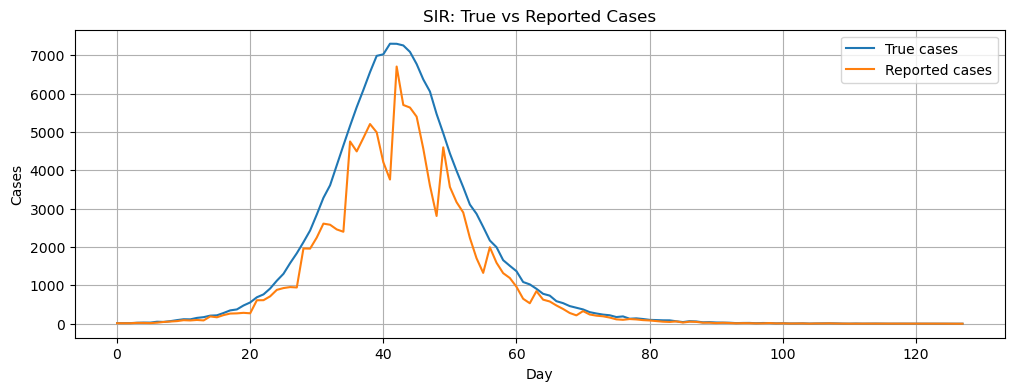

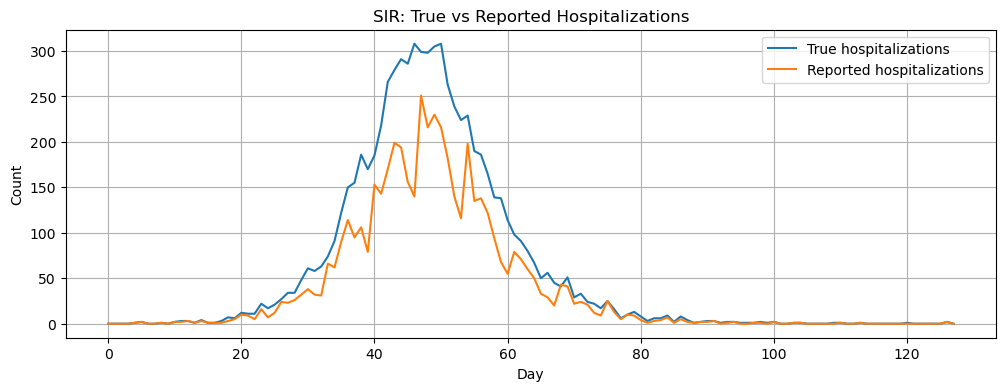

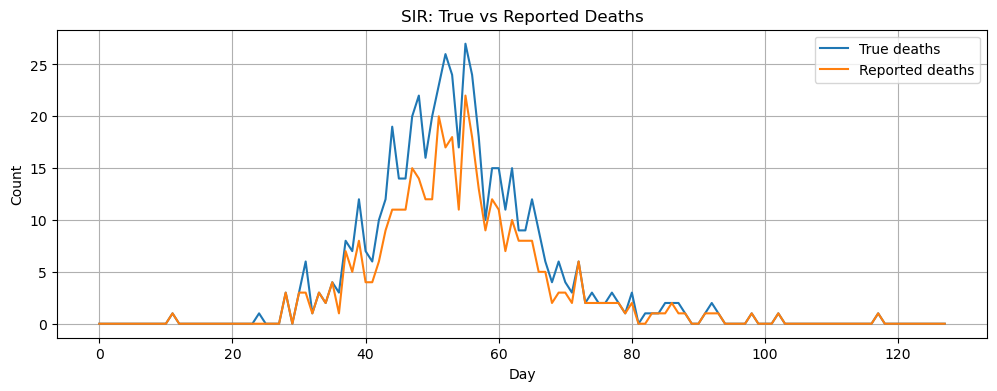

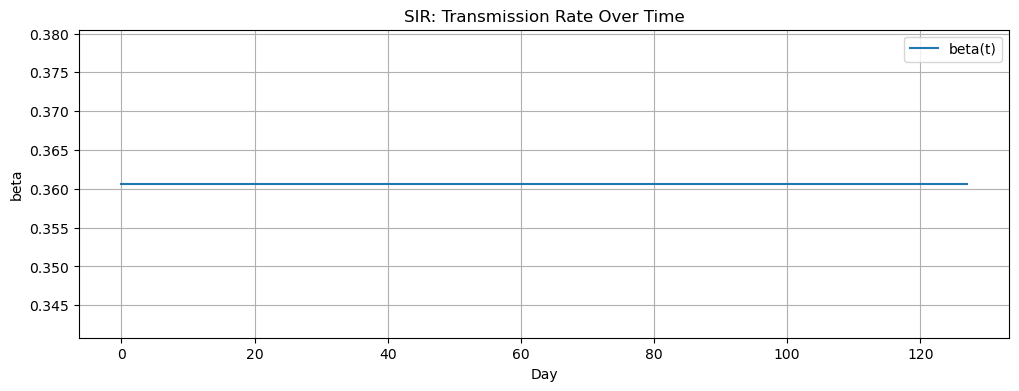

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(sir_example["daily_new_cases_true"], label="True cases")
plt.plot(sir_example["daily_new_cases_reported"], label="Reported cases")
plt.title("SIR: True vs Reported Cases")
plt.xlabel("Day")
plt.ylabel("Cases")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sir_example["daily_hosp_true"], label="True hospitalizations")
plt.plot(sir_example["daily_hosp_reported"], label="Reported hospitalizations")
plt.title("SIR: True vs Reported Hospitalizations")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sir_example["daily_death_true"], label="True deaths")
plt.plot(sir_example["daily_death_reported"], label="Reported deaths")
plt.title("SIR: True vs Reported Deaths")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sir_example["beta_t"], label="beta(t)")
plt.title("SIR: Transmission Rate Over Time")
plt.xlabel("Day")
plt.ylabel("beta")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# SEIR Simulation

# N = population size; T = Number of days
def simulate_seir(N = 200000, T = 128):
    # Random starting values
    # Transmission rate (beta-how fast infection spreads)
    beta = np.random.uniform(0.15, 0.45)
    
    # exposed -> infected rate
    sigma = np.random.uniform(0.15, 0.50)
    # Recovery rate (gamma-how fast people recover)
    gamma = np.random.uniform(0.07, 0.25)
    
    # Exposed people - Initial number of exposed people between 5 and 49
    E0 = np.random.randint(5, 50)
    
    # starting values
    # S-Susceptible people who can catch the disease
    S = N - E0
    #E-Exposed people
    E = E0
    # I-Infected people
    I = 0
    # R-Recovered people
    R = 0

    # history lists
    S_hist = []
    E_hist = []
    I_hist = []
    R_hist = []

    # New infections each day
    new_inf_hist = []
    new_inc_hist = []

    # Sample NPI settings for this outbreak
    npi_params = sample_npi_parameters(N)
    npi_state = {
        "active": False,
        "start_day": None,
        "days_active": 0,
        "below_off_threshold_days": 0
    }

    # Store beta for each day
    beta_t_hist = []
    
    # simulating for for every day
    # This loop runs for each day from T = 0 to T = 127
    for day in range(T):
        beta_today = get_beta_with_npi(
            day=day,
            beta=beta,
            daily_new_cases=new_inc_hist,
            npi_params=npi_params,
            npi_state=npi_state
        )
        beta_t_hist.append(beta_today)
        
        # how strongly infection spreads today
        # calculates infection pressure for the day
        force = beta_today * I / N

        # expected new infections (susceptible to exposed)
        expected_new_inf = force * S
        # random number for new infections
        new_inf = np.random.poisson(expected_new_inf)

        # This makes sure new infections cannot be more than the number of susceptible people left.
        new_inf = min(new_inf, int(S))

        # new exposed people become infected (exposed to infected)
        expected_new_inc = sigma * E
        #random number for exposed
        new_inc = np.random.poisson(expected_new_inc)
        new_inc = min(new_inc, int(E))
      
        # expected new recoveries
        expected_new_rec = gamma * I
        # random number for new recoveries
        new_rec = np.random.poisson(expected_new_rec)
        # This makes sure recoveries cannot be more than the number of infected people.
        new_rec = min(new_rec, int(I))

        # updating the counts of S, I, R
        S = S - new_inf
        E = E + new_inf - new_inc
        I = I + new_inc - new_rec
        R = R + new_rec

        # storing the daily values
        S_hist.append(S)
        E_hist.append(E)
        I_hist.append(I)
        R_hist.append(R)
        new_inf_hist.append(new_inf)
        new_inc_hist.append(new_inc)

    # Converting true daily infections to NumPy array
    daily_new_cases_true = np.array(new_inc_hist, dtype=int)

    # adding reporting noise to true cases
    daily_new_cases_reported, reporting_info = add_reporting_noise(daily_new_cases_true)

    # remove reported cases after true outbreak
    daily_new_cases_reported = enforce_no_post_outbreak_cases(daily_new_cases_true, daily_new_cases_reported)

    # hospitalization and death from true daily cases
    daily_hosp_true, daily_death_true, hospital_death_info = (generate_hospitalizations_and_deaths(daily_new_cases_true))

    # reporting noise to hosiptalization
    daily_hosp_reported, hosp_reporting_info = add_reporting_noise(daily_hosp_true)
    # removing reported hospitalization after outbreak
    daily_hosp_reported = enforce_no_post_outbreak_cases(daily_hosp_true, daily_hosp_reported)

    # reporting noise to deaths
    daily_death_reported, death_reporting_info = add_reporting_noise(daily_death_true)
    # removing reported deaths after outbreak
    daily_death_reported = enforce_no_post_outbreak_cases(daily_death_true, daily_death_reported)

    # Dictionary that the function will return
    return {
        "model_type": "SEIR",
        "population": N,
        "beta": beta,
        "sigma": sigma,
        "gamma": gamma,
        "E0": E0,

        # saving NPI setting
        "npi_enabled": npi_params["npi_enabled"],
        "npi_on_threshold": npi_params["npi_on_threshold"],
        "npi_off_threshold": npi_params["npi_off_threshold"],
        "npi_delay": npi_params["npi_delay"],
        "npi_reduction": npi_params["npi_reduction"],
        "npi_min_duration": npi_params["npi_min_duration"],
        "npi_off_days_required": npi_params["npi_off_days_required"],

        #Save beta values ovet time
        "beta_t": np.array(beta_t_hist, dtype=float),

        # saving infection outcomes
        "daily_new_cases_true": daily_new_cases_true,
        "daily_new_cases_reported": np.array(daily_new_cases_reported, dtype=int),

        # saving hospital outcomes
        "daily_hosp_true": np.array(daily_hosp_true, dtype=int),
        "daily_hosp_reported": np.array(daily_hosp_reported, dtype=int),

        # saving deaths outcomes
        "daily_death_true": np.array(daily_death_true, dtype=int),
        "daily_death_reported": np.array(daily_death_reported, dtype=int),

        # Save reporting and hospitalization
        "reporting_info_cases": reporting_info,
        "reporting_info_hosp": hosp_reporting_info,
        "reporting_info_death": death_reporting_info,
        "hospital_death_info": hospital_death_info,

        # combining the four history lists (susceptible, exposed, infected, recovered)
        "compartments": np.stack([S_hist, E_hist, I_hist, R_hist], axis=1)
    }

In [11]:
# Simulation for SEAIR

# N - population size; T - Number of days
def simulate_seair(N = 200000, T = 128):
    # Random starting values
    # Transmission rate (beta-how fast infection spreads)
    beta = np.random.uniform(0.15, 0.45)
    # exposed - infected rate
    sigma = np.random.uniform(0.15, 0.50)
    # recovery rate for asymptomatic
    gamma_a = np.random.uniform(0.07, 0.25)
    # recovery rate for symptomatic
    gamma_i = np.random.uniform(0.07, 0.25)
    # chance of exposed becoming asymptomatic
    p_a = np.random.uniform(0.2, 0.6)
    # starting exposed people
    E0 = np.random.randint(5, 50)

    # starting values
    # S-Susceptible people who can catch the disease
    S = N - E0
    # E-Exposed
    E = E0
    # A-Asymptomatic
    A = 0
    # I-Infected
    I = 0
    # R-Recovered
    R = 0

    # history lists
    S_hist = []
    E_hist = []
    A_hist = []
    I_hist = []
    R_hist = []
    # New infections each day
    new_inf_hist = []
    new_inc_hist = []
    new_symp_hist = []

    # Sample NPI settings for this outbreak
    npi_params = sample_npi_parameters(N)
    npi_state = {
        "active": False,
        "start_day": None,
        "days_active": 0,
        "below_off_threshold_days": 0
    }
    beta_t_hist = []

    
    # simulating for each day
    # This loop runs for each day from T = 0 to T = 127
    for day in range(T):

        beta_today = get_beta_with_npi(
            day=day,
            beta=beta,
            daily_new_cases=new_symp_hist,
            npi_params=npi_params,
            npi_state=npi_state
        )
        beta_t_hist.append(beta_today)
        
        # infection spread strength (from asymptomatic and symptomatic people)
        # calculates infection pressure for the day
        force = beta_today * (A + I) / N

        # expected new infections (S to E)
        expected_new_inf = force * S
        # random number for new infections
        new_inf = np.random.poisson(expected_new_inf)
        new_inf = min(new_inf, int(S))
        
        # exposed people become infected
        expected_new_inc = sigma * E
        # random number for people moving from exposed to infectious
        new_inc = np.random.poisson(expected_new_inc)
        # This makes sure new infections cannot be more than the number of susceptible people left.
        new_inc = min(new_inc, int(E))

        # split new infectious people into asymptomatic and symptomatic
        to_A = np.random.binomial(new_inc, p_a)
        to_I = new_inc - to_A

        # expected number of recoveries from asymptomatic and symptomatic people
        expected_rec_a = gamma_a * A #anymptomatic
        expected_rec_i = gamma_i * I #symptomatic

        # random number for recoveries
        rec_a = np.random.poisson(expected_rec_a)
        rec_i = np.random.poisson(expected_rec_i)

        # This makes sure recoveries cannot be more than the number of infected people.
        rec_a = min(rec_a, int(A))
        rec_i = min(rec_i, int(I))
    
        # updated counts for S, E, A, I, R
        S = S - new_inf             #succeptable
        E = E + new_inf - new_inc   #exposed
        A = A + to_A - rec_a        #asymptomatic infected
        I = I + to_I - rec_i        #symptomatic infected
        R = R + rec_a + rec_i       #recovery
    
        # storing the daily values
        S_hist.append(S)
        E_hist.append(E)
        A_hist.append(A)
        I_hist.append(I)
        R_hist.append(R)
        new_inf_hist.append(new_inf)
        new_inc_hist.append(new_inc)
        new_symp_hist.append(to_I)

    # Converting true daily infections to NumPy array
    daily_new_cases_true = np.array(new_inc_hist, dtype=int)

    # adding reporting noise to true cases
    daily_new_cases_reported, reporting_info = add_reporting_noise(daily_new_cases_true)
    # remove reported cases after true outbreak
    daily_new_cases_reported = enforce_no_post_outbreak_cases(daily_new_cases_true, daily_new_cases_reported)

    # hospitalization and death from true daily cases
    daily_hosp_true, daily_death_true, hospital_death_info = (generate_hospitalizations_and_deaths(new_symp_hist))

    # reporting noise to hosiptalization
    daily_hosp_reported, hosp_reporting_info = add_reporting_noise(daily_hosp_true)
    # removing reported hospitalization after outbreak
    daily_hosp_reported = enforce_no_post_outbreak_cases(daily_hosp_true, daily_hosp_reported)

    # reporting noise to deaths
    daily_death_reported, death_reporting_info = add_reporting_noise(daily_death_true)
    # removing reported deaths after outbreak
    daily_death_reported = enforce_no_post_outbreak_cases(daily_death_true, daily_death_reported)
  
    # Dictionary that the function will return
    return {
        "model_type": "SEAIR",
        "population": N,
        "beta": beta,
        "sigma": sigma,
        "gamma_a": gamma_a,
        "gamma_i": gamma_i,
        "p_a": p_a,
        "E0": E0,

        # saving NPI setting
        "npi_enabled": npi_params["npi_enabled"],
        "npi_on_threshold": npi_params["npi_on_threshold"],
        "npi_off_threshold": npi_params["npi_off_threshold"],
        "npi_delay": npi_params["npi_delay"],
        "npi_reduction": npi_params["npi_reduction"],
        "npi_min_duration": npi_params["npi_min_duration"],
        "npi_off_days_required": npi_params["npi_off_days_required"],

        #Save beta values ovet time
        "beta_t": np.array(beta_t_hist, dtype=float),

        # saving infection outcomes
        "daily_new_cases_true": np.array(daily_new_cases_true, dtype=int),
        "daily_new_cases_reported": np.array(daily_new_cases_reported, dtype=int),

        # saving hospital outcomes
        "daily_hosp_true": np.array(daily_hosp_true, dtype=int),
        "daily_hosp_reported": np.array(daily_hosp_reported, dtype=int),

        # saving deaths outcomes
        "daily_death_true": np.array(daily_death_true, dtype=int),
        "daily_death_reported": np.array(daily_death_reported, dtype=int),

        # Save reporting and hospitalization
        "reporting_info_cases": reporting_info,
        "reporting_info_hosp": hosp_reporting_info,
        "reporting_info_death": death_reporting_info,
        "hospital_death_info": hospital_death_info,

        # combining the five history lists (susceptible, exposed, asymptomatic, infected, recovered)
        "compartments": np.stack([S_hist, E_hist, A_hist, I_hist, R_hist], axis=1)
    }

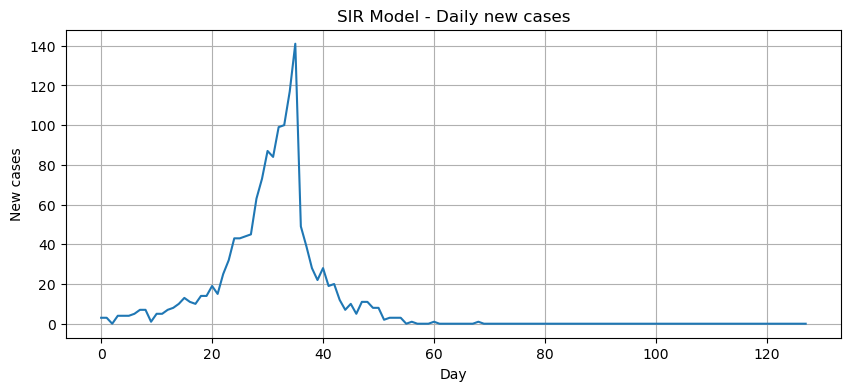

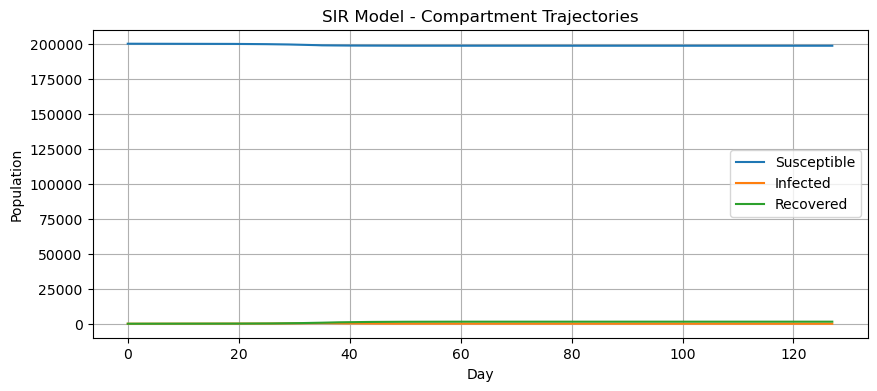

In [12]:
# running one SIR simulation
sir_sample = simulate_sir()

# Extracting outputs
daily_cases = sir_sample["daily_new_cases_true"]
compartments = sir_sample["compartments"]

# Plotting daily new cases
plt.figure(figsize=(10, 4))
plt.plot(daily_cases)
plt.title("SIR Model - Daily new cases")
plt.xlabel("Day")
plt.ylabel("New cases")
plt.grid(True)
plt.show()

# Compartments
plt.figure(figsize=(10, 4))

plt.plot(compartments[:, 0], label="Susceptible")
plt.plot(compartments[:, 1], label="Infected")
plt.plot(compartments[:, 2], label="Recovered")

plt.title("SIR Model - Compartment Trajectories")
plt.xlabel("Day")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

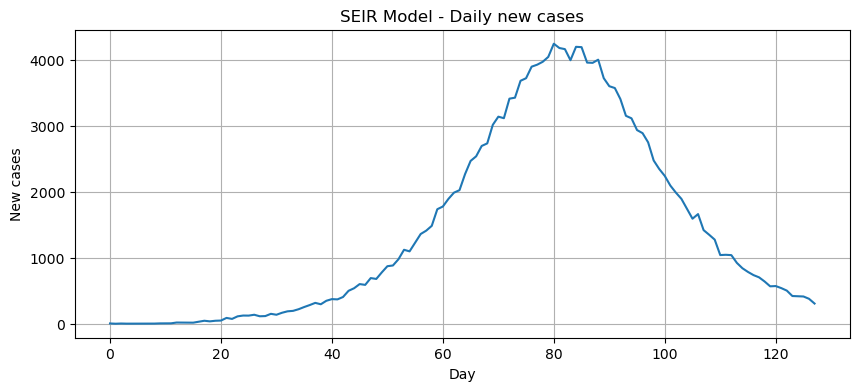

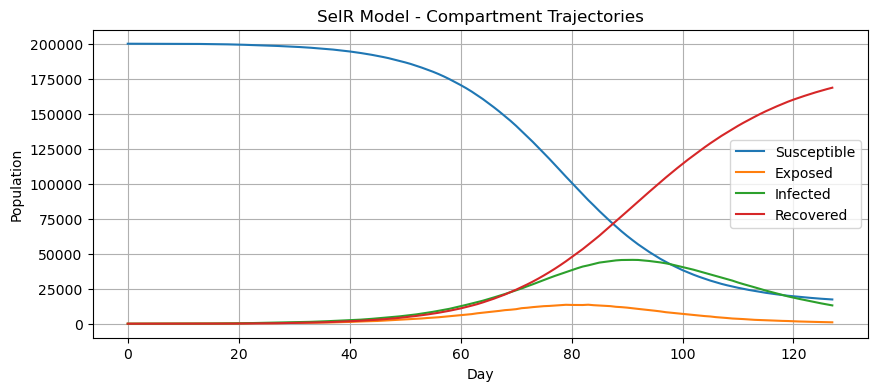

In [13]:
# running one SEIR simulation
seir_sample = simulate_seir()

# Extracting outputs
daily_cases = seir_sample["daily_new_cases_true"]
compartments = seir_sample["compartments"]

# Plotting daily new cases
plt.figure(figsize=(10, 4))
plt.plot(daily_cases)

plt.title("SEIR Model - Daily new cases")
plt.xlabel("Day")
plt.ylabel("New cases")
plt.grid(True)
plt.show()

# Compartments
plt.figure(figsize=(10, 4))

plt.plot(compartments[:, 0], label="Susceptible")
plt.plot(compartments[:, 1], label="Exposed")
plt.plot(compartments[:, 2], label="Infected")
plt.plot(compartments[:, 3], label="Recovered")


plt.title("SeIR Model - Compartment Trajectories")
plt.xlabel("Day")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

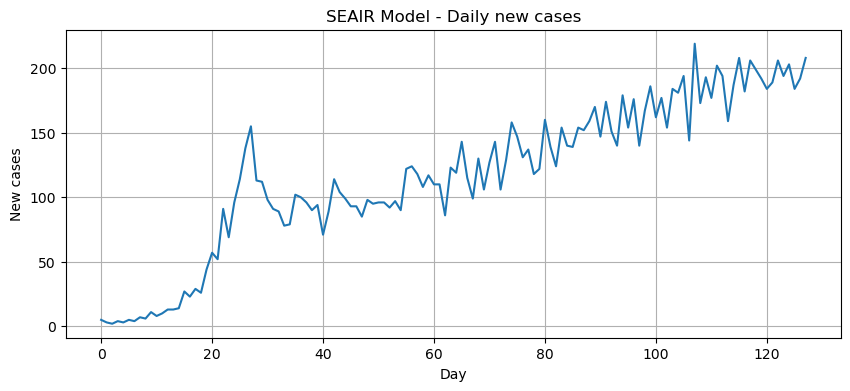

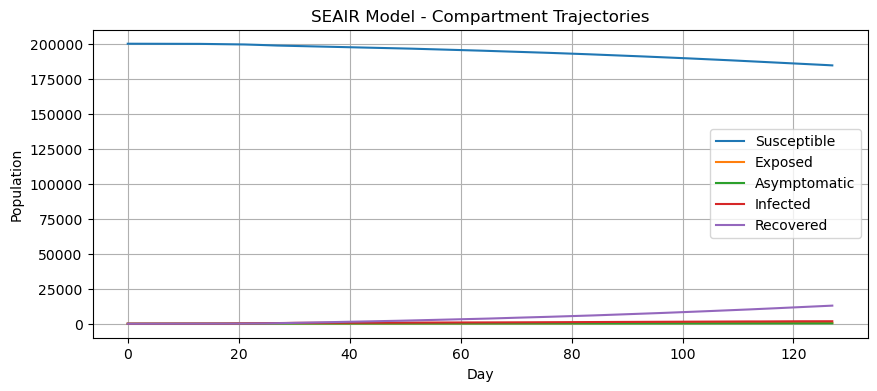

In [14]:
# running one SEAIR simulation
seair_sample = simulate_seair()

# Extracting outputs
daily_cases = seair_sample["daily_new_cases_true"]
compartments = seair_sample["compartments"]

# Plotting daily new cases
plt.figure(figsize=(10, 4))
plt.plot(daily_cases)

plt.title("SEAIR Model - Daily new cases")
plt.xlabel("Day")
plt.ylabel("New cases")
plt.grid(True)
plt.show()

# Compartments
plt.figure(figsize=(10, 4))

plt.plot(compartments[:, 0], label="Susceptible")
plt.plot(compartments[:, 1], label="Exposed")
plt.plot(compartments[:, 2], label="Asymptomatic")
plt.plot(compartments[:, 3], label="Infected")
plt.plot(compartments[:, 4], label="Recovered")

plt.title("SEAIR Model - Compartment Trajectories")
plt.xlabel("Day")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Function to create one outbreak sample

def simulate_one_sample(N=200000, T=128):
    # Randomly choosing epidemic model to use: SIR, SEIR, or SEAIR
    model_name = np.random.choice(["SIR", "SEIR", "SEAIR"])

    # If the chosen model is SIR, run the SIR simulation
    if model_name == "SIR":
        return simulate_sir(N=N, T=T)

    # If the chosen model is SEIR, run the SEIR simulation
    elif model_name == "SEIR":
        return simulate_seir(N=N, T=T)

    # Otherwise, use the SEAIR simulation
    else:
        return simulate_seair(N=N, T=T)

In [16]:
sample = simulate_one_sample()

print("Model type:", sample["model_type"])
print("First 10 daily cases:", sample["daily_new_cases_true"][:10])
print("Compartment shape:", sample["compartments"].shape)

Model type: SEIR
First 10 daily cases: [5 0 4 1 0 1 0 1 1 1]
Compartment shape: (128, 4)


In [17]:
# Generating many outbreaks and building dataset

def generate_dataset(num_samples=1000, N=200000, T=128):
    # Store one dictionary per outbreak sample
    rows = []

    # Repeating the simulation num_sample times
    for i in range(num_samples):

        # GEnerating one outbreak sample
        sample = simulate_one_sample(N=N, T=T)
        
        # Storing model information
        row = {
            # Store model name (SIR, SEIR, or SEAIR)
            "model_type": sample["model_type"],
            
            # Store the population size used in the simulation
            "population": sample["population"],
            
            # Store model parameters if they exist
            "beta": sample.get("beta", np.nan),
            "gamma": sample.get("gamma", np.nan),
            "sigma": sample.get("sigma", np.nan),
            "gamma_a": sample.get("gamma_a", np.nan),
            "gamma_i": sample.get("gamma_i", np.nan),
            "p_a": sample.get("p_a", np.nan),
            "I0": sample.get("I0", np.nan),
            "E0": sample.get("E0", np.nan),

            # Store NPI parameters if they exist
            "npi_enabled": sample.get("npi_enabled", np.nan),
            "npi_on_threshold": sample.get("npi_on_threshold", np.nan),
            "npi_off_threshold": sample.get("npi_off_threshold", np.nan),
            "npi_delay": sample.get("npi_delay", np.nan),
            "npi_reduction": sample.get("npi_reduction", np.nan),
            "npi_min_duration": sample.get("npi_min_duration", np.nan),
            "npi_off_days_required": sample.get("npi_off_days_required", np.nan)
        }
        
        # Store daily true and reported case counts
        for t in range(T):
            row[f"true_cases_day_{t}"] = sample["daily_new_cases_true"][t]
            row[f"reported_cases_day_{t}"] = sample["daily_new_cases_reported"][t]
            
            row[f"hosp_true_day_{t}"] = sample["daily_hosp_true"][t]
            row[f"hosp_reported_day_{t}"] = sample["daily_hosp_reported"][t]
            row[f"death_true_day_{t}"] = sample["daily_death_true"][t]
            row[f"death_reported_day_{t}"] = sample["daily_death_reported"][t]

        # Adding the outbreak row to the list
        rows.append(row)

    # List to pandas dataframe
    return pd.DataFrame(rows)

In [18]:
# Generating the dataset
df = generate_dataset(num_samples=1000, N=200000, T=128)

# Printing shape of the dataset
print("Dataset shape:", df.shape)

# Model counts
print("\nModel counts:")

#
#print(df["model_type"].value_counts())

# Printing first few rows of the data
df.head()

Dataset shape: (1000, 785)

Model counts:


,model_type,population,beta,gamma,sigma,gamma_a,gamma_i,p_a,I0,E0,...,hosp_true_day_126,hosp_reported_day_126,death_true_day_126,death_reported_day_126,true_cases_day_127,reported_cases_day_127,hosp_true_day_127,hosp_reported_day_127,death_true_day_127,death_reported_day_127
0,SEIR,200000,0.344114,0.151823,0.219324,NaN,NaN,NaN,NaN,44.0,...,20,20,5,4,477,433,20,19,4,4
1,SEIR,200000,0.367405,0.153944,0.181775,NaN,NaN,NaN,NaN,43.0,...,3,3,0,0,29,28,1,0,1,1
2,SIR,200000,0.340595,0.218379,NaN,NaN,NaN,NaN,30.0,NaN,...,12,8,3,3,33,31,7,7,1,1
3,SEAIR,200000,0.418032,NaN,0.151836,0.223322,0.116956,0.248776,NaN,48.0,...,21,19,0,0,459,431,12,10,0,0
4,SEAIR,200000,0.357632,NaN,0.344952,0.189353,0.202465,0.559227,NaN,14.0,...,171,96,21,15,1930,1154,147,144,20,16


In [19]:
# saving dataset
df.to_csv("sir_seir_seair_dataset.csv", index=False)


In [20]:
# Choosing input and target days

# First 100 days as input
input_days = 100

# predict next 28 days 
target_days = 28

In [21]:
# Building input and target column names
# This creates two sets of column names that the model will use- input days and target days

# This is creating column names ["reported_cases_day_0", "reported_cases_day_1", "reported_cases_day_99"]
input_cols = [f"reported_cases_day_{t}" for t in range(input_days)]

# This is creating column names ["reported_cases_day_100", "reported_cases_day_101", "reported_cases_day_127"]
target_cols = [f"reported_cases_day_{t}" for t in range(input_days, input_days + target_days)]

In [22]:
# Creating X (input data or features) and y (target data) arrays
# X contains the first 100 days of reported daily cases, 
# and y contains the next 28 days of reported daily cases that the model should predict

# This turns pandas dataframe to NumPy array. This is done so that it works better with PyTorch.

X = df[input_cols].to_numpy(dtype=np.float32)
y = df[target_cols].to_numpy(dtype=np.float32)

# printing shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 100)
y shape: (1000, 28)


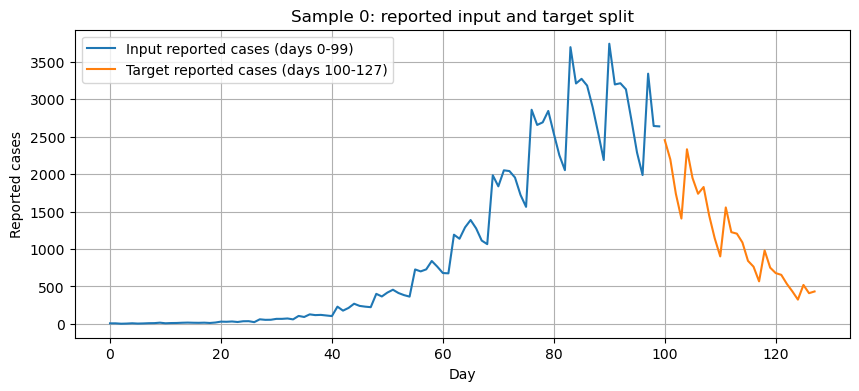

In [23]:
# Plotting one sample outbreak 
sample_idx = 0
x_input = np.arange(input_days)
x_target = np.arange(input_days, input_days + target_days)

plt.figure(figsize=(10, 4))
plt.plot(x_input, X[sample_idx], label="Input reported cases (days 0-99)")
plt.plot(x_target, y[sample_idx], label="Target reported cases (days 100-127)")
plt.title(f"Sample {sample_idx}: reported input and target split")
plt.xlabel("Day")
plt.ylabel("Reported cases")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
# 80/20 train-test split
# This splits the reported-case input and target arrays into training data and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 100)
X_test shape: (200, 100)
y_train shape: (800, 28)
y_test shape: (200, 28)


In [25]:
# Converting NumPy arrays to PyTorch tensors. This is the data type PyTorch model expects
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [26]:
# Simple neural network

# Input: first 100 days of reported cases
# Output: next 28 days of reported cases
# 100 inputs; one hiddel layer with 64 neurons; 28 outputs
# ReLU() is the activation function that adds nonlinearity and helps the model learn more complex patterns

model = nn.Sequential(nn.Linear(100, 64), nn.ReLU(), nn.Linear(64, 28))

In [27]:
# Defining loss and optimizer

# This creates the loss function: MSELoss - Mean squared error
criterion = nn.MSELoss()

# This creates the optimizer
# Adam is the method that updates the model's weight so the loss gets smaller
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model for 50 full passes through the training data
epochs = 50

# storing loss from each epoch
train_losses = []

for epoch in range(epochs):
    model.train()

    # clears old gradiants from previous step
    optimizer.zero_grad()

    # Model prediction on all training samples
    y_pred = model(X_train_tensor)

    # Comparing the predictions with the true training values and calculates the error
    loss = criterion(y_pred, y_train_tensor)
    
    # computes gradients
    loss.backward()

    # Updates model weights
    optimizer.step()

    # Saves training loss
    train_losses.append(loss.item())

    # Printing progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss= {loss.item(): .6f}")

Epoch 5/50, Loss=  555239.062500
Epoch 10/50, Loss=  483390.218750
Epoch 15/50, Loss=  419439.125000
Epoch 20/50, Loss=  360573.156250
Epoch 25/50, Loss=  309534.531250
Epoch 30/50, Loss=  266703.187500
Epoch 35/50, Loss=  232113.781250
Epoch 40/50, Loss=  205303.125000
Epoch 45/50, Loss=  183982.703125
Epoch 50/50, Loss=  167212.734375


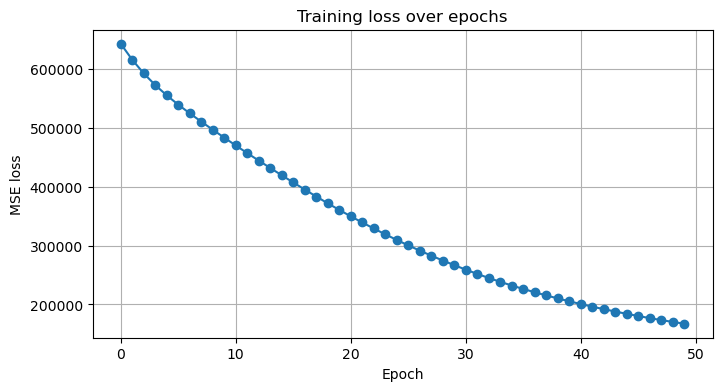

In [28]:
# Training loss Plot

plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker="o")
plt.title("Training loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

In [29]:
## Test evaluation step. It is for checking how well the trained model works on data it has not seen before:

# Model in evaluation mode
model.eval()
with torch.no_grad():
    # Predict in test set
    test_pred = model(X_test_tensor)

    # compute test loss
    test_loss = criterion(test_pred, y_test_tensor)

    # prediction in NumPy
    predictions = test_pred.numpy()

print("Average test loss:", test_loss.item())

# computing mean absolute error MAE
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
print("Test MAE:", round(mae, 2))

Average test loss: 94701.921875
Test MAE: 147.16


The above output shows that the squared prediction error on unseen test set is quite large  
Average test loss: 293357.90625  
Test MAE: 323.11

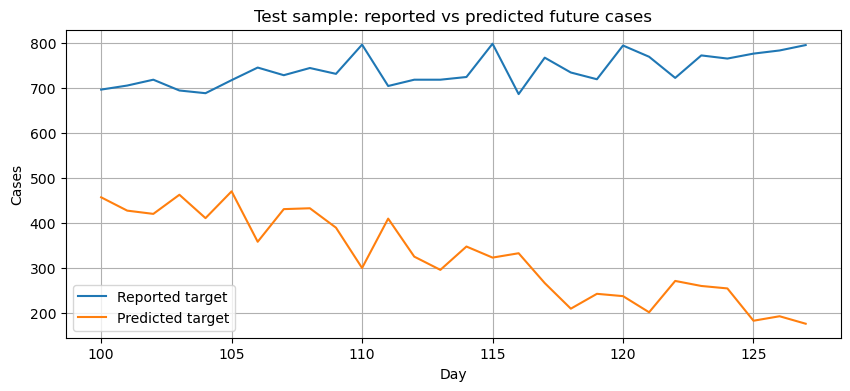

In [30]:
# prediction plot for one test example
# shows whether the predicted curve follows the real curve

with torch.no_grad():
    #predicting one test sample
    sample_prediction = model(X_test_tensor[0:1]).numpy()[0]

# true target for same sample
sample_true = y_test_tensor[0].numpy()
x_target = np.arange(input_days, input_days + target_days)

plt.figure(figsize=(10, 4))
plt.plot(x_target, sample_true, label="Reported target")
plt.plot(x_target, sample_prediction, label="Predicted target")

plt.title("Test sample: reported vs predicted future cases")
plt.xlabel("Day")
plt.ylabel("Cases")
plt.grid(True)
plt.legend()
plt.show()

# The above code takes one test outbreak, gets the model's predictions for next 28 days, 
# then plots it against the true values so we can see how sell the model performed




- The above plot compares the true future cases with the predicted future cases for one test sample.
- Blue Line is real target and the orange is the line that the model prediction
- The predicted line follows the downward trend but it is lower than the true curve.
- Blue line starts at around 3700 cases but the orange line starts much lower at around 2200
- The model is not matching the exact values very well. It underestimates the cases count
- The model has still a lot of room for improvement


In [31]:
# obtining the COVID-19 data
url = "https://health-infobase.canada.ca/covid-19/"

In [32]:
# downloading data
csv_url = "https://health-infobase.canada.ca/src/data/covidLive/covid19-download.csv"
df_real = pd.read_csv(csv_url)
df_real.head()



,pruid,prname,prnameFR,date,reporting_week,reporting_year,update,totalcases,numtotal_last7,ratecases_total,...,ratecases_last7,ratedeaths_last7,numtotal_last14,numdeaths_last14,ratetotal_last14,ratedeaths_last14,avgcases_last7,avgincidence_last7,avgdeaths_last7,avgratedeaths_last7
0,59,British Columbia,Colombie-Britannique,2020-02-08,6,2020,1.0,4,3,0.07,...,0.05,0.0,4,0.0,0.07,0.0,0.43,0.01,0.0,0.0
1,48,Alberta,Alberta,2020-02-08,6,2020,1.0,0,0,0,...,0,0.0,0,0.0,0,0.0,0,0,0.0,0.0
2,47,Saskatchewan,Saskatchewan,2020-02-08,6,2020,1.0,0,0,0,...,0,0.0,0,0.0,0,0.0,0,0,0.0,0.0
3,46,Manitoba,Manitoba,2020-02-08,6,2020,1.0,0,0,0,...,0,0.0,0,0.0,0,0.0,0,0,0.0,0.0
4,35,Ontario,Ontario,2020-02-08,6,2020,1.0,4,1,0.03,...,0.01,0.0,1,0.0,0.01,0.0,0.14,0,0.0,0.0


In [33]:
# column names
print(df_real.columns.tolist())

['pruid', 'prname', 'prnameFR', 'date', 'reporting_week', 'reporting_year', 'update', 'totalcases', 'numtotal_last7', 'ratecases_total', 'numdeaths', 'numdeaths_last7', 'ratedeaths', 'ratecases_last7', 'ratedeaths_last7', 'numtotal_last14', 'numdeaths_last14', 'ratetotal_last14', 'ratedeaths_last14', 'avgcases_last7', 'avgincidence_last7', 'avgdeaths_last7', 'avgratedeaths_last7']


In [34]:
# Keep Newfoundland and Labrador only
nl = df_real[df_real["prname"] == "Newfoundland and Labrador"].copy()

# Make date a proper datetime column
nl["date"] = pd.to_datetime(nl["date"])

# Sort by date
nl = nl.sort_values("date")

# Keeping only the useful columns
nl = nl[["date", "totalcases", "numtotal_last7", "numdeaths", "numdeaths_last7"]]

nl.head()

,date,totalcases,numtotal_last7,numdeaths,numdeaths_last7
6,2020-02-08,0,0,0,0.0
21,2020-02-15,0,0,0,0.0
36,2020-02-22,0,0,0,0.0
51,2020-02-29,0,0,0,0.0
66,2020-03-07,0,0,0,0.0


In [35]:
# Remove missing values if needed
nl = nl.dropna(subset=["numtotal_last7"])

# Choose a 4-week window
nl_4wk = nl.tail(4).copy()

print(nl_4wk)

           date totalcases numtotal_last7  numdeaths  numdeaths_last7
3576 2024-08-31          -              -        427              1.0
3591 2024-09-07          -              -        428              1.0
3606 2024-09-14          -              -        429              1.0
3621 2024-09-21          -              -        429              0.0


In [36]:
# Suppose sample_reported_cases is your simulated reported daily cases
sample_reported_cases = df.loc[0, [f"reported_cases_day_{t}" for t in range(128)]].to_numpy()

# Turn daily cases into 4 weekly totals
sim_weekly = [
    sample_reported_cases[0:7].sum(),
    sample_reported_cases[7:14].sum(),
    sample_reported_cases[14:21].sum(),
    sample_reported_cases[21:28].sum()
]

print(sim_weekly)

[np.int64(38), np.int64(81), np.int64(122), np.int64(240)]


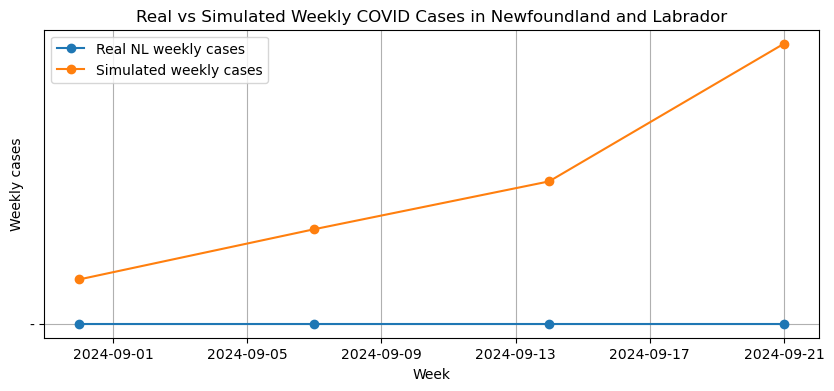

In [37]:
plt.figure(figsize=(10, 4))

plt.plot(nl_4wk["date"], nl_4wk["numtotal_last7"], marker="o", label="Real NL weekly cases")
plt.plot(nl_4wk["date"], sim_weekly, marker="o", label="Simulated weekly cases")

plt.title("Real vs Simulated Weekly COVID Cases in Newfoundland and Labrador")
plt.xlabel("Week")
plt.ylabel("Weekly cases")
plt.grid(True)
plt.legend()
plt.show()